![imagen](Airbnb.png)

# Exercise 6

Airbnb wants to know how much room prices vary in the downtown area (Centrum-Oost and Centrum-West). To do this, they’re asking you to determine how significant the differences in room prices are by property type (room_type) in this part of the city, since they’ve noticed that prices can be very similar in the downtown area.

* Answer the question by performing an ANOVA analysis. 

# 1. Import libraries

In [1]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load data

In [2]:
data= pd.read_csv('listings_m-6-.csv', sep=',')

In [3]:
pd.set_option('display.max_columns', None)
data.head(2)

,id,listing_url,scrape_id,last_scraped,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2818,https://www.airbnb.com/rooms/2818,2.021040e+13,12/04/2021,Quiet Garden View Room & Super Fast WiFi,Quiet Garden View Room & Super Fast WiFi<br />...,"Indische Buurt (""Indies Neighborhood"") is a ne...",https://a0.muscache.com/pictures/10272854/8dcc...,3159,https://www.airbnb.com/users/show/3159,Daniel,24/09/2008,"Amsterdam, Noord-Holland, The Netherlands","Upon arriving in Amsterdam, one can imagine as...",NaN,NaN,NaN,t,https://a0.muscache.com/im/users/3159/profile_...,https://a0.muscache.com/im/users/3159/profile_...,Indische Buurt,1.0,1.0,"['email', 'phone', 'reviews', 'jumio', 'offlin...",t,t,"Amsterdam, North Holland, Netherlands",Oostelijk Havengebied - Indische Buurt,NaN,"5,236,435","494,358",Private room in apartment,Private room,2,NaN,1.5 shared baths,1.0,2.0,"[""Long term stays allowed"", ""Wifi"", ""Hot water...",59,3,1125,3.0,3.0,1125.0,1125.0,3.0,1125.0,NaN,t,13,43,62,152,12/04/2021,278,0,0,30/03/2009,14/02/2020,98.0,10.0,10.0,10.0,10.0,9.0,10.0,NaN,t,1,0,1,0,1.9
1,20168,https://www.airbnb.com/rooms/20168,2.021040e+13,12/04/2021,Studio with private bathroom in the centre 1,17th century Dutch townhouse in the heart of t...,Located just in between famous central canals....,https://a0.muscache.com/pictures/69979628/fd6a...,59484,https://www.airbnb.com/users/show/59484,Alexander,02/12/2009,"Amsterdam, Noord-Holland, The Netherlands",#¿NOMBRE?,NaN,NaN,NaN,f,https://a0.muscache.com/im/pictures/user/65092...,https://a0.muscache.com/im/pictures/user/65092...,Grachtengordel,2.0,2.0,"['email', 'phone', 'reviews', 'jumio', 'offlin...",t,t,"Amsterdam, North Holland, Netherlands",Centrum-Oost,NaN,"5,236,407","489,393",Private room in townhouse,Private room,2,NaN,1 private bath,1.0,1.0,"[""Essentials"", ""TV"", ""Host greets you"", ""Wifi""...",200,1,365,1.0,4.0,365.0,1125.0,3.3,554.1,NaN,t,0,0,0,0,12/04/2021,339,0,0,02/03/2010,09/04/2020,89.0,10.0,10.0,10.0,10.0,10.0,9.0,0363 CBB3 2C10 0C2A 1E29,t,2,0,2,0,2.5


# 3. ANOVA

In [4]:
neighbourhood = data[
    (data['neighbourhood_cleansed'].isin(['Centrum-Oost', 'Centrum-West'])) 
][['neighbourhood_cleansed', 'room_type', 'price']]
neighbourhood.head()

,neighbourhood_cleansed,room_type,price
1,Centrum-Oost,Private room,200
2,Centrum-West,Entire home/apt,125
3,Centrum-West,Private room,141
4,Centrum-West,Private room,75
5,Centrum-Oost,Private room,55


### 3.1 Hypothesis testing

$H₀: μ₁ = μ₂ = μ₃ =… $

$H₁:$ No todos los $μᵢ$ son iguales, donde $i = 1, 2, 3,….$

In [11]:
entire = neighbourhood[neighbourhood['room_type'] == 'Entire home/apt']['price']
private = neighbourhood[neighbourhood['room_type'] == 'Private room']['price']
shared = neighbourhood[neighbourhood['room_type'] == 'Shared room']['price']
hotel = neighbourhood[neighbourhood['room_type'] == 'Hotel room']['price']

In [12]:
f_stat, p_value = stats.f_oneway(entire, private, shared, hotel)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")

F-statistic: 52.7304
p-value: 0.0000


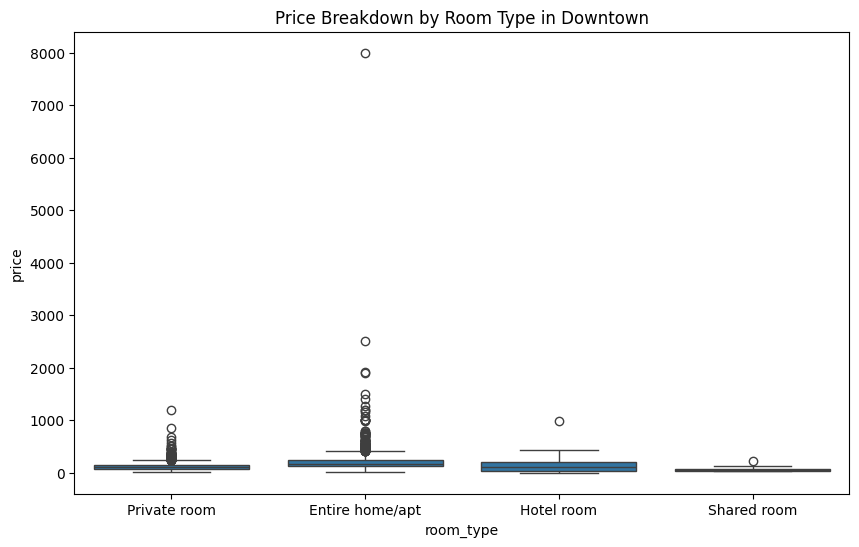

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='room_type', y='price', data=neighbourhood)
plt.title('Price Breakdown by Room Type in Downtown')
plt.show()

#### A one-way analysis of variance (ANOVA) was conducted to assess the influence of accommodation type on price within the downtown area. The results showed a p-value of 0.0000. Under a standard significance level of alpha = 0.05%, since p < alpha, the null hypothesis H0 is rejected. Therefore, there is sufficient statistical evidence to conclude that the price differences between room categories are highly significant and are not due to chance.